# Train trên TPU v6e-1 - Chứng minh Reproducibility Issues

**TPU Target**: Google Cloud TPU v6e-1  
**Architecture**: v6e (Edge TPU)  
**TF32 Support**: ❌ Không hỗ trợ (TF32 là tính năng NVIDIA GPU)  
**Precision**: BFloat16 (mặc định cho TPU), FP32

**Mục tiêu**: Train cùng mô hình, cùng seed trên TPU v6e-1 và so sánh với các GPU khác.

**Lưu ý**:
- TPU v6e-1 không hỗ trợ TF32 (đây là tính năng NVIDIA GPU)
- TPU sử dụng bfloat16 mặc định cho hiệu suất tốt hơn
- Chạy notebook này trên hệ thống có TPU v6e-1 (Google Cloud hoặc Colab)
- Cần cài đặt `torch_xla` để sử dụng PyTorch trên TPU
- Kết quả sẽ được lưu vào `results/` để so sánh với các GPU khác


## 1. Cài đặt torch_xla và kiểm tra TPU


In [10]:
# Cài đặt torch_xla (chạy lần đầu tiên)
# !pip install torch_xla[tpu] -f https://storage.googleapis.com/libtpu-releases/index.html

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os

# Import torch_xla cho TPU
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.parallel_loader as pl
    # Import runtime module cho world_size (torch_xla 2.7+)
    try:
        import torch_xla.runtime as xr
        RUNTIME_AVAILABLE = True
    except ImportError:
        RUNTIME_AVAILABLE = False
    TPU_AVAILABLE = True
    print(f"torch_xla version: {torch_xla.__version__}")
except ImportError:
    TPU_AVAILABLE = False
    RUNTIME_AVAILABLE = False
    print("⚠️  torch_xla chưa được cài đặt!")
    print("   Chạy: !pip install torch_xla[tpu] -f https://storage.googleapis.com/libtpu-releases/index.html")

# Kiểm tra TPU
print(f"\nPyTorch version: {torch.__version__}")
if TPU_AVAILABLE:
    # Sử dụng torch_xla.device() thay vì xm.xla_device() (deprecated)
    try:
        device = torch_xla.device()
    except:
        device = xm.xla_device()  # Fallback cho phiên bản cũ
    print(f"TPU Device: {device}")

    # Lấy device hardware info
    try:
        device_hw = xm.xla_device_hw(device)
        print(f"TPU Device Type: {device_hw}")
    except:
        device_hw = "Unknown"
        print(f"TPU Device Type: {device_hw}")

    # Kiểm tra số TPU cores - sử dụng API mới
    try:
        if RUNTIME_AVAILABLE:
            num_cores = xr.world_size()
        else:
            # Fallback: thử API cũ hoặc đặt mặc định
            try:
                num_cores = xm.xrt_world_size()
            except:
                num_cores = 1  # Mặc định nếu không lấy được
        print(f"Số TPU cores: {num_cores}")
    except Exception as e:
        print(f"Không thể lấy số TPU cores: {e}")
        num_cores = 1

    # Xác nhận TPU v6e-1
    if "v6e" in device_hw.lower() or "v6" in device_hw.lower():
        print(f"\n✓ Đã xác nhận: TPU v6e")
    else:
        print(f"\n⚠️  CẢNH BÁO: TPU hiện tại ({device_hw}) có thể không phải v6e-1!")
        print("   Notebook này được thiết kế cho TPU v6e-1.")
        print("   Vẫn tiếp tục nhưng kết quả có thể khác.")
else:
    print("❌ Không tìm thấy TPU hoặc torch_xla chưa được cài đặt!")
    print("   Vui lòng cài đặt torch_xla và đảm bảo bạn đang chạy trên TPU VM hoặc Colab với TPU.")


torch_xla version: 2.9.0

PyTorch version: 2.9.0+cpu
TPU Device: xla:0
TPU Device Type: TPU
Số TPU cores: 1

⚠️  CẢNH BÁO: TPU hiện tại (TPU) có thể không phải v6e-1!
   Notebook này được thiết kế cho TPU v6e-1.
   Vẫn tiếp tục nhưng kết quả có thể khác.


## 2. Hàm thiết lập seed và môi trường


In [11]:
def set_seed(seed=42):
    """Thiết lập seed cho tất cả các RNG để đảm bảo reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    # TPU không có cuda, nên không cần torch.cuda.manual_seed

def setup_environment(bf16_enabled=True, amp_enabled=False, num_workers=4):
    """
    Thiết lập môi trường với các cấu hình khác nhau

    Args:
        bf16_enabled: Bật/tắt BFloat16 (TPU hỗ trợ tốt, mặc định bật)
        amp_enabled: Bật/tắt Automatic Mixed Precision (không cần thiết với TPU)
        num_workers: Số worker cho DataLoader (mặc định 4 cho Linux/Unix)
    """
    # TPU không có TF32 (đây là tính năng NVIDIA GPU)
    # TPU sử dụng bfloat16 mặc định cho hiệu suất tốt hơn

    if TPU_AVAILABLE:
        try:
            # Sử dụng torch_xla.device() thay vì xm.xla_device() (deprecated)
            try:
                device = torch_xla.device()
            except:
                device = xm.xla_device()  # Fallback cho phiên bản cũ
            tpu_name = xm.xla_device_hw(device)
        except:
            tpu_name = 'Unknown'

        # Lấy số cores - sử dụng API mới
        try:
            if RUNTIME_AVAILABLE:
                num_cores = xr.world_size()
            else:
                try:
                    num_cores = xm.xrt_world_size()
                except:
                    num_cores = 1
        except:
            num_cores = 1

        # Thêm gpu_name để tương thích với notebook phân tích (sử dụng tpu_name)
        device_name = f"TPU {tpu_name}"
    else:
        tpu_name = 'N/A'
        num_cores = 0
        device_name = 'N/A'

    config = {
        'tf32_enabled': False,  # TPU không hỗ trợ TF32
        'bf16_enabled': bf16_enabled,  # TPU hỗ trợ bfloat16
        'amp_enabled': amp_enabled,
        'num_workers': num_workers,
        'tpu_name': tpu_name,  # Tên TPU cụ thể
        'gpu_name': device_name,  # Tương thích với notebook phân tích
        'num_cores': num_cores
    }

    return config


## 3. Định nghĩa mô hình đơn giản (CNN cho CIFAR-10)


In [12]:
class SimpleCNN(nn.Module):
    """Mô hình CNN đơn giản với BatchNorm và Dropout để dễ thấy sự khác biệt"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # CIFAR-10: 32x32 -> 16x16 -> 8x8 -> 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


## 4. Load dữ liệu CIFAR-10


In [13]:
def get_cifar10_loaders(batch_size=128, num_workers=4, seed=42):
    """Load CIFAR-10 với preprocessing chuẩn (tối ưu cho Linux/Unix)"""
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    # Set seed cho DataLoader
    def worker_init_fn(worker_id):
        np.random.seed(seed + worker_id)

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, worker_init_fn=worker_init_fn if num_workers > 0 else None,
        pin_memory=True
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test
    )
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
        pin_memory=True
    )

    return trainloader, testloader


## 5. Hàm training với logging chi tiết (cho TPU)


In [14]:
def train_one_epoch(model, trainloader, criterion, optimizer, device, bf16_enabled=False):
    """Train một epoch trên TPU và trả về loss trung bình"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # TPU sử dụng bfloat16 mặc định
        if bf16_enabled:
            # Sử dụng torch.autocast với device_type='xla' cho TPU
            with torch.autocast(device_type='xla', dtype=torch.bfloat16):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        loss.backward()

        # Sử dụng xm.optimizer_step() cho TPU thay vì optimizer.step()
        xm.optimizer_step(optimizer)

        # Đồng bộ TPU sau mỗi step
        xm.mark_step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, testloader, criterion, device):
    """Evaluate trên test set"""
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Đồng bộ TPU
            xm.mark_step()

    test_loss = test_loss / len(testloader)
    test_acc = 100. * correct / total
    return test_loss, test_acc


## 6. Hàm train đầy đủ với logging


In [15]:
def train_model(config, seed=42, num_epochs=10, save_results=True):
    """
    Train mô hình với cấu hình cụ thể và lưu kết quả

    Returns:
        dict: Kết quả training bao gồm loss, accuracy theo epoch
    """
    if not TPU_AVAILABLE:
        print("❌ TPU không khả dụng! Vui lòng cài đặt torch_xla và đảm bảo bạn đang chạy trên TPU.")
        return None

    # Setup
    set_seed(seed)
    device = xm.xla_device()

    # Load data
    trainloader, testloader = get_cifar10_loaders(
        batch_size=128,
        num_workers=config['num_workers'],
        seed=seed
    )

    # Model
    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'config': config,
        'seed': seed
    }

    print(f"\n{'='*60}")
    print(f"Training trên TPU v6e-1 với cấu hình:")
    print(f"  TPU: {config['tpu_name']}")
    print(f"  Số cores: {config['num_cores']}")
    print(f"  TF32: {config['tf32_enabled']} (TPU không hỗ trợ)")
    print(f"  BFloat16: {config['bf16_enabled']}")
    print(f"  AMP: {config['amp_enabled']}")
    print(f"  Num Workers: {config['num_workers']}")
    print(f"  Seed: {seed}")
    print(f"{'='*60}\n")

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, trainloader, criterion, optimizer, device,
            bf16_enabled=config['bf16_enabled']
        )
        test_loss, test_acc = evaluate(model, testloader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    # Lưu kết quả
    if save_results:
        os.makedirs('results', exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f"results/train_TPU_v6e1_bf16_{config['bf16_enabled']}_amp_{config['amp_enabled']}_{timestamp}.json"

        with open(filename, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"\n✓ Kết quả đã lưu: {filename}")
        print(f"  → Copy file này để so sánh với các GPU khác trong notebook 03")

    return history


In [7]:
# Test 1: Cấu hình mặc định cho TPU v6e-1 (BFloat16, không TF32, num_workers=4)
config_default = setup_environment(bf16_enabled=True, amp_enabled=False, num_workers=4)
history_default = train_model(config_default, seed=42, num_epochs=10)


/tmp/ipython-input-3033956228.py:14: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()
100%|██████████| 170M/170M [00:06<00:00, 26.0MB/s]



Training trên TPU v6e-1 với cấu hình:
  TPU: TPU
  Số cores: 1
  TF32: False (TPU không hỗ trợ)
  BFloat16: True
  AMP: False
  Num Workers: 4
  Seed: 42



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-2943475006.py:29: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-2943475006.py:59: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10:
  Train Loss: 1.4508, Train Acc: 46.49%
  Test Loss: 1.1383, Test Acc: 58.69%
Epoch 2/10:
  Train Loss: 1.1394, Train Acc: 59.30%
  Test Loss: 0.9153, Test Acc: 67.63%
Epoch 3/10:
  Train Loss: 1.0214, Train Acc: 63.55%
  Test Loss: 0.8735, Test Acc: 69.16%
Epoch 4/10:
  Train Loss: 0.9399, Train Acc: 66.63%
  Test Loss: 0.8367, Test Acc: 70.52%
Epoch 5/10:
  Train Loss: 0.8926, Train Acc: 68.41%
  Test Loss: 0.7595, Test Acc: 73.30%
Epoch 6/10:
  Train Loss: 0.8539, Train Acc: 69.62%
  Test Loss: 0.7481, Test Acc: 73.44%
Epoch 7/10:
  Train Loss: 0.8218, Train Acc: 70.76%
  Test Loss: 0.6976, Test Acc: 75.68%
Epoch 8/10:
  Train Loss: 0.7926, Train Acc: 72.08%
  Test Loss: 0.6724, Test Acc: 76.50%
Epoch 9/10:
  Train Loss: 0.7585, Train Acc: 73.27%
  Test Loss: 0.6684, Test Acc: 76.89%
Epoch 10/10:
  Train Loss: 0.7469, Train Acc: 73.54%
  Test Loss: 0.6555, Test Acc: 76.82%

✓ Kết quả đã lưu: results/train_TPU_v6e1_bf16_True_amp_False_20251226_040346.json
  → Copy file nà

### 7.2 Test với BFloat16 tắt (FP32)


In [8]:
# Test 2: FP32 (BFloat16 tắt)
config_fp32 = setup_environment(bf16_enabled=False, amp_enabled=False, num_workers=4)
history_fp32 = train_model(config_fp32, seed=42, num_epochs=10)

# Test 3: num_workers=0 để loại bỏ non-determinism từ DataLoader
config_no_workers = setup_environment(bf16_enabled=True, amp_enabled=False, num_workers=0)
history_no_workers = train_model(config_no_workers, seed=42, num_epochs=10)


/tmp/ipython-input-3033956228.py:14: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()



Training trên TPU v6e-1 với cấu hình:
  TPU: TPU
  Số cores: 1
  TF32: False (TPU không hỗ trợ)
  BFloat16: False
  AMP: False
  Num Workers: 4
  Seed: 42



/tmp/ipython-input-2943475006.py:29: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-2943475006.py:59: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10:
  Train Loss: 1.4551, Train Acc: 46.61%
  Test Loss: 1.1729, Test Acc: 57.42%
Epoch 2/10:
  Train Loss: 1.1374, Train Acc: 58.92%
  Test Loss: 0.9280, Test Acc: 67.00%
Epoch 3/10:
  Train Loss: 1.0210, Train Acc: 63.47%
  Test Loss: 0.8459, Test Acc: 70.29%
Epoch 4/10:
  Train Loss: 0.9499, Train Acc: 66.20%
  Test Loss: 0.8404, Test Acc: 70.35%
Epoch 5/10:
  Train Loss: 0.8915, Train Acc: 68.44%
  Test Loss: 0.7648, Test Acc: 73.15%
Epoch 6/10:
  Train Loss: 0.8528, Train Acc: 69.68%
  Test Loss: 0.7407, Test Acc: 73.91%
Epoch 7/10:
  Train Loss: 0.8216, Train Acc: 70.96%
  Test Loss: 0.7495, Test Acc: 74.32%
Epoch 8/10:
  Train Loss: 0.7926, Train Acc: 71.91%
  Test Loss: 0.6761, Test Acc: 75.79%
Epoch 9/10:
  Train Loss: 0.7657, Train Acc: 73.09%
  Test Loss: 0.6508, Test Acc: 77.47%
Epoch 10/10:
  Train Loss: 0.7436, Train Acc: 73.78%
  Test Loss: 0.6707, Test Acc: 76.64%

✓ Kết quả đã lưu: results/train_TPU_v6e1_bf16_False_amp_False_20251226_040501.json
  → Copy file n

## 8. So sánh kết quả trên TPU v6e-1


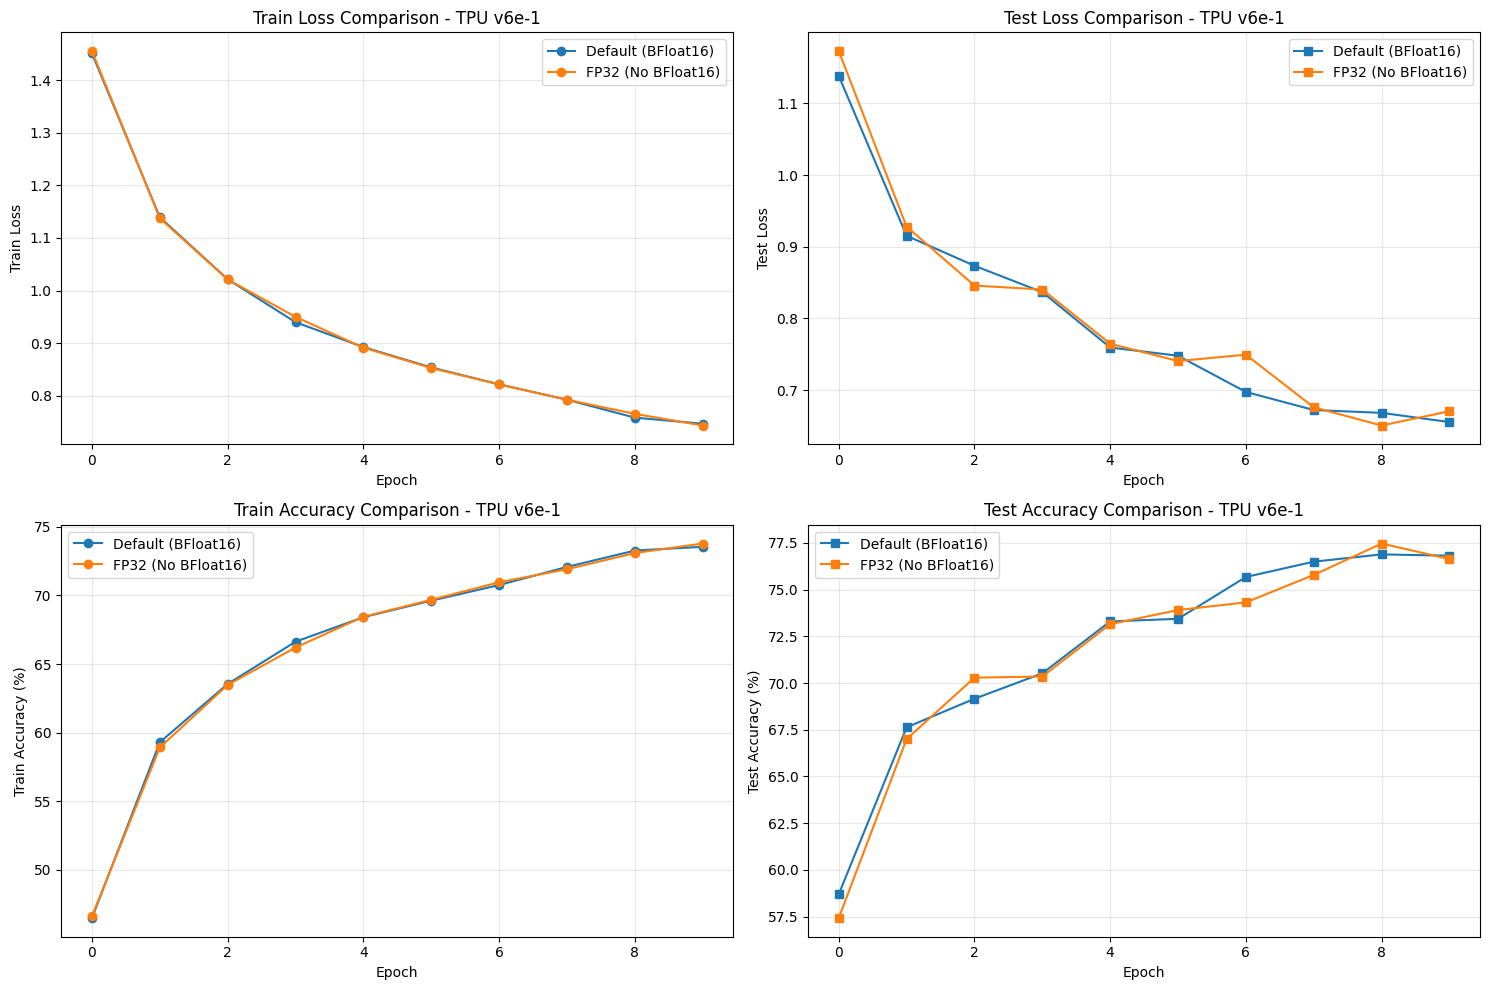


BẢNG SO SÁNH KẾT QUẢ CUỐI CÙNG - TPU v6e-1
Cấu hình                                 Train Loss   Test Loss    Test Acc    
--------------------------------------------------------------------------------
Default (BFloat16)                       0.7469       0.6555       76.82       %
FP32 (No BFloat16)                       0.7436       0.6707       76.64       %


In [9]:
def compare_results(histories, labels):
    """So sánh và visualize kết quả từ nhiều lần train"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Train Loss
    ax = axes[0, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_loss'], label=label, marker='o')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title('Train Loss Comparison - TPU v6e-1')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Test Loss
    ax = axes[0, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_loss'], label=label, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Loss')
    ax.set_title('Test Loss Comparison - TPU v6e-1')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Train Accuracy
    ax = axes[1, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_acc'], label=label, marker='o')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Accuracy (%)')
    ax.set_title('Train Accuracy Comparison - TPU v6e-1')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Test Accuracy
    ax = axes[1, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_acc'], label=label, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Test Accuracy Comparison - TPU v6e-1')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/comparison_TPU_v6e1.png', dpi=150, bbox_inches='tight')
    plt.show()

    # In bảng so sánh
    print("\n" + "="*80)
    print("BẢNG SO SÁNH KẾT QUẢ CUỐI CÙNG - TPU v6e-1")
    print("="*80)
    print(f"{'Cấu hình':<40} {'Train Loss':<12} {'Test Loss':<12} {'Test Acc':<12}")
    print("-"*80)
    for hist, label in zip(histories, labels):
        final_train_loss = hist['train_loss'][-1]
        final_test_loss = hist['test_loss'][-1]
        final_test_acc = hist['test_acc'][-1]
        print(f"{label:<40} {final_train_loss:<12.4f} {final_test_loss:<12.4f} {final_test_acc:<12.2f}%")
    print("="*80)

# So sánh các kết quả (nếu có)
if 'history_default' in globals() and 'history_fp32' in globals() and 'history_no_workers' in globals():
    if history_default is not None and history_fp32 is not None and history_no_workers is not None:
        histories_to_compare = [history_default, history_fp32, history_no_workers]
        labels_to_compare = [
            f"Default (BFloat16)",
            f"FP32 (No BFloat16)"
        ]
        compare_results(histories_to_compare, labels_to_compare)


## 9. Kết luận cho TPU v6e-1

**Đặc điểm TPU v6e-1**:
- Architecture: v6e (Edge TPU)
- ❌ Không hỗ trợ TF32 (đây là tính năng NVIDIA GPU)
- ✅ Hỗ trợ BFloat16 (mặc định cho hiệu suất tốt hơn)
- ✅ Hỗ trợ FP32

**Vấn đề Reproducibility trên TPU**:
- **XLA Compilation**: TPU sử dụng XLA (Accelerated Linear Algebra) compiler, có thể tạo ra các kernel khác nhau giữa các lần chạy
- **BFloat16 Precision**: Sử dụng bfloat16 có thể dẫn đến khác biệt số học so với FP32
- **Multi-core Synchronization**: TPU có nhiều cores, việc đồng bộ có thể ảnh hưởng đến reproducibility
- **DataLoader**: Tương tự GPU, num_workers > 0 có thể gây non-determinism

**Kết quả**:
- Kết quả đã được lưu vào thư mục `results/`
- File JSON có thể được dùng để so sánh với các GPU khác trong notebook `04_analyze_cross_gpu_results.ipynb`

**Bước tiếp theo**:
1. Chạy các notebook tương tự trên GPU khác (T4, L4, A100, RTX 3060)
2. Copy tất cả file JSON vào cùng thư mục `results/`
3. Chạy notebook `04_analyze_cross_gpu_results.ipynb` để so sánh giữa TPU và GPU
